In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [22]:
# --- Hyperparameters ---
latent_dim = 100
hidden_dim = 256
image_dim = 784   # 28x28 flattened MNIST images
num_epochs = 500  
batch_size = 128
# Lower learning rate. 0.002 is too high for GANs; 0.0002 is standard.
learning_rate = 0.0002
dataset_size = 1000 # LIMIT TO 1000 IMAGES

In [23]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [24]:
# --- 1. Load MNIST (Digits) Subset ---
transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize([0.5], [0.5]) 
])

full_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)

# LIMIT DATASET HERE
train_dataset = torch.utils.data.Subset(full_dataset, range(dataset_size))

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
print(f"Training on {len(train_dataset)} images.")

Training on 1000 images.


In [25]:
# --- 2. Generator Network ---
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            # Input: Latent Vector (z)
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),     # FIX: BatchNorm stabilizes learning
            nn.LeakyReLU(0.2),              # FIX: LeakyReLU prevents dead neurons
            
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.LeakyReLU(0.2),
            
            nn.Linear(hidden_dim * 2, hidden_dim * 4),
            nn.BatchNorm1d(hidden_dim * 4),
            nn.LeakyReLU(0.2),
            
            nn.Linear(hidden_dim * 4, image_dim),
            nn.Tanh()  # Output must be [-1, 1] to match image normalization
        )
    
    def forward(self, z):
        return self.model(z)

# --- 3. Discriminator Network ---
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(image_dim, hidden_dim * 4),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),  # FIX: Dropout prevents D from memorizing/overpowering G
            
            nn.Linear(hidden_dim * 4, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()  # Output probability [0, 1]
        )
    
    def forward(self, img):
        return self.model(img.view(img.size(0), -1)) # Flatten image

In [26]:
# Initialize models
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Optimizers: Adam with Betas (0.5, 0.999) is standard for stable GANs
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(0.5, 0.999))

criterion = nn.BCELoss()

In [27]:
# --- 4. Training Loop ---
def train_gan():
    print("Starting Training...")
    d_losses, g_losses = [], []
    
    for epoch in range(num_epochs):
        for i, (real_imgs, _) in enumerate(train_loader):
            batch_size_current = real_imgs.size(0)
            real_imgs = real_imgs.to(device)
            
            # --- LABELS with SMOOTHING ---
            # FIX: Real labels = 0.9 instead of 1.0. 
            # This prevents Discriminator from becoming too confident (D_loss -> 0).
            real_labels = torch.full((batch_size_current, 1), 0.9).to(device)
            fake_labels = torch.zeros(batch_size_current, 1).to(device)
            
            # ---------------------
            #  Train Discriminator
            # ---------------------
            d_optimizer.zero_grad()
            
            # Real Images
            real_output = discriminator(real_imgs)
            d_real_loss = criterion(real_output, real_labels)
            
            # Fake Images
            z = torch.randn(batch_size_current, latent_dim).to(device)
            fake_imgs = generator(z)
            fake_output = discriminator(fake_imgs.detach()) # Detach to avoid training G here
            d_fake_loss = criterion(fake_output, fake_labels)
            
            d_loss = d_real_loss + d_fake_loss
            d_loss.backward()
            d_optimizer.step()
            
            # -----------------
            #  Train Generator
            # -----------------
            g_optimizer.zero_grad()
            
            # Generate fresh fakes (optional, but using previous batch is fine too)
            fake_output = discriminator(fake_imgs) 
            
            # Generator wants to fool D, so target is REAL (1.0)
            target_labels = torch.ones(batch_size_current, 1).to(device)
            
            g_loss = criterion(fake_output, target_labels)
            g_loss.backward()
            g_optimizer.step()
        
        d_losses.append(d_loss.item())
        g_losses.append(g_loss.item())
        
        if epoch % 10 == 0:
            print(f'Epoch [{epoch}/{num_epochs}] D loss: {d_loss.item():.4f}, G loss: {g_loss.item():.4f}')

    return d_losses, g_losses

In [28]:
# Run Training
d_losses, g_losses = train_gan()

Starting Training...
Epoch [0/500] D loss: 1.1923, G loss: 0.7242
Epoch [10/500] D loss: 1.4644, G loss: 0.9475
Epoch [20/500] D loss: 1.2104, G loss: 1.0187
Epoch [30/500] D loss: 1.1621, G loss: 1.1133
Epoch [40/500] D loss: 1.1192, G loss: 0.9705
Epoch [50/500] D loss: 1.2388, G loss: 0.9234
Epoch [60/500] D loss: 1.1858, G loss: 0.8317
Epoch [70/500] D loss: 1.0903, G loss: 1.2456
Epoch [80/500] D loss: 1.0863, G loss: 1.0619
Epoch [90/500] D loss: 1.0707, G loss: 1.0488
Epoch [100/500] D loss: 1.4968, G loss: 1.5792
Epoch [110/500] D loss: 1.1283, G loss: 1.1781
Epoch [120/500] D loss: 1.6150, G loss: 0.9946
Epoch [130/500] D loss: 1.1344, G loss: 2.1780
Epoch [140/500] D loss: 1.2676, G loss: 2.0947
Epoch [150/500] D loss: 1.1694, G loss: 0.8433
Epoch [160/500] D loss: 1.0452, G loss: 1.2325
Epoch [170/500] D loss: 1.2025, G loss: 2.1963
Epoch [180/500] D loss: 1.0757, G loss: 0.9803
Epoch [190/500] D loss: 1.1985, G loss: 0.7244
Epoch [200/500] D loss: 1.0010, G loss: 1.1490
Epo

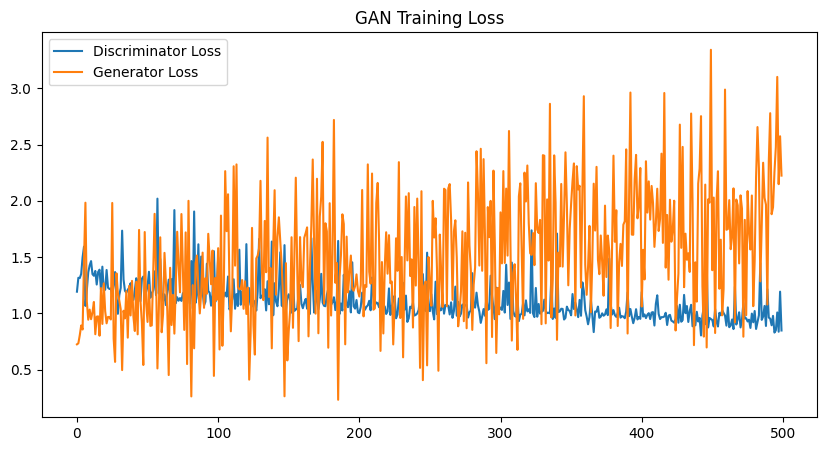

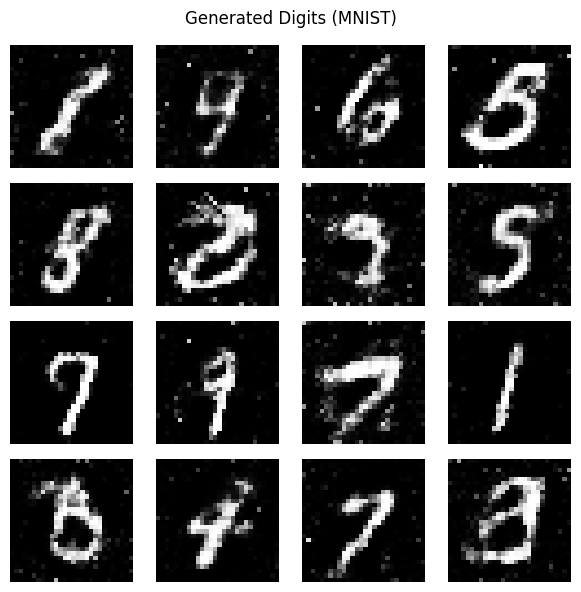

In [29]:
# --- 5. Visualization ---
def visualize_results(d_losses, g_losses):
    # Plot Loss
    plt.figure(figsize=(10, 5))
    plt.plot(d_losses, label='Discriminator Loss')
    plt.plot(g_losses, label='Generator Loss')
    plt.legend()
    plt.title("GAN Training Loss")
    plt.show()

    # Generate and Show Images
    generator.eval()
    z = torch.randn(16, latent_dim).to(device)
    with torch.no_grad():
        fake_imgs = generator(z).detach().cpu().numpy()
    
    # Denormalize [-1, 1] -> [0, 1]
    fake_imgs = (fake_imgs.reshape(16, 28, 28) + 1) / 2 
    
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_imgs[i], cmap='gray')
        ax.axis('off')
    plt.suptitle("Generated Digits (MNIST)")
    plt.tight_layout()
    plt.show()

visualize_results(d_losses, g_losses)

In [30]:

# Classify real/fake using trained Discriminator
def classify_images(real_imgs, fake_imgs):
    discriminator.eval()
    with torch.no_grad():
        real_probs = discriminator(real_imgs.to(device)).cpu().numpy()
        fake_probs = discriminator(fake_imgs.to(device)).cpu().numpy()
    
    # Sample a few for demo
    num_samples = 5
    print("\nClassification Results (Probability of being REAL):")
    print("Real Images:")
    for i in range(min(num_samples, len(real_probs))):
        prob = real_probs[i].item()
        pred = "Real" if prob > 0.5 else "Fake"
        print(f"Image {i+1}: Prob = {prob:.4f} -> {pred}")
    
    print("Fake Images:")
    for i in range(min(num_samples, len(fake_probs))):
        prob = fake_probs[i].item()
        pred = "Real" if prob > 0.5 else "Fake"
        print(f"Image {i+1}: Prob = {prob:.4f} -> {pred}")

# Demo classification: Use a batch of real and generated fake
real_batch, _ = next(iter(train_loader))
z_demo = torch.randn(batch_size, latent_dim).to(device)
fake_batch = generator(z_demo).detach()

classify_images(real_batch, fake_batch)  # Pass full batch


Classification Results (Probability of being REAL):
Real Images:
Image 1: Prob = 0.8296 -> Real
Image 2: Prob = 0.6251 -> Real
Image 3: Prob = 0.8728 -> Real
Image 4: Prob = 0.5955 -> Real
Image 5: Prob = 0.8697 -> Real
Fake Images:
Image 1: Prob = 0.1241 -> Fake
Image 2: Prob = 0.4074 -> Fake
Image 3: Prob = 0.3409 -> Fake
Image 4: Prob = 0.1639 -> Fake
Image 5: Prob = 0.0366 -> Fake
